#House Price Prediction using Machine Learning
##Objective

Predict house prices based on various housing features such as median income, house age, average rooms, population, and geographical location using machine learning techniques. The project aims to build and evaluate regression models for accurate house price prediction.

##Dataset

California Housing Dataset (Scikit-learn)

##Machine Learning Type

Supervised Learning → Regression

##Algorithms Used
Linear Regression
Random Forest Regressor

# Phase 1: Data Collection and Loading

The California Housing Dataset was loaded using Scikit-learn and converted into a Pandas DataFrame. This dataset contains various housing-related features and a target variable representing house prices.

In [17]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Phase 2: Exploratory Data Analysis (EDA)

EDA was performed to understand the structure, distribution, and quality of the dataset. Statistical summaries, missing value analysis, histograms, and correlation analysis were used to gain insights into the data.
## 2.1 Dataset Overview

The dataset structure was examined using shape, head, and info functions to understand the number of records, features, and data types.

In [33]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [18]:
df.shape

(20640, 9)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## 2.2 Statistical Summary

Descriptive statistics were generated to analyze the central tendency, spread, and range of numerical features.

In [20]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 2.3 Missing Value Analysis

The dataset was checked for missing values to ensure data quality before model training.

In [21]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


## 2.4 Feature Distribution Analysis

Histograms were plotted to visualize the distribution of each feature and identify possible skewness or outliers.

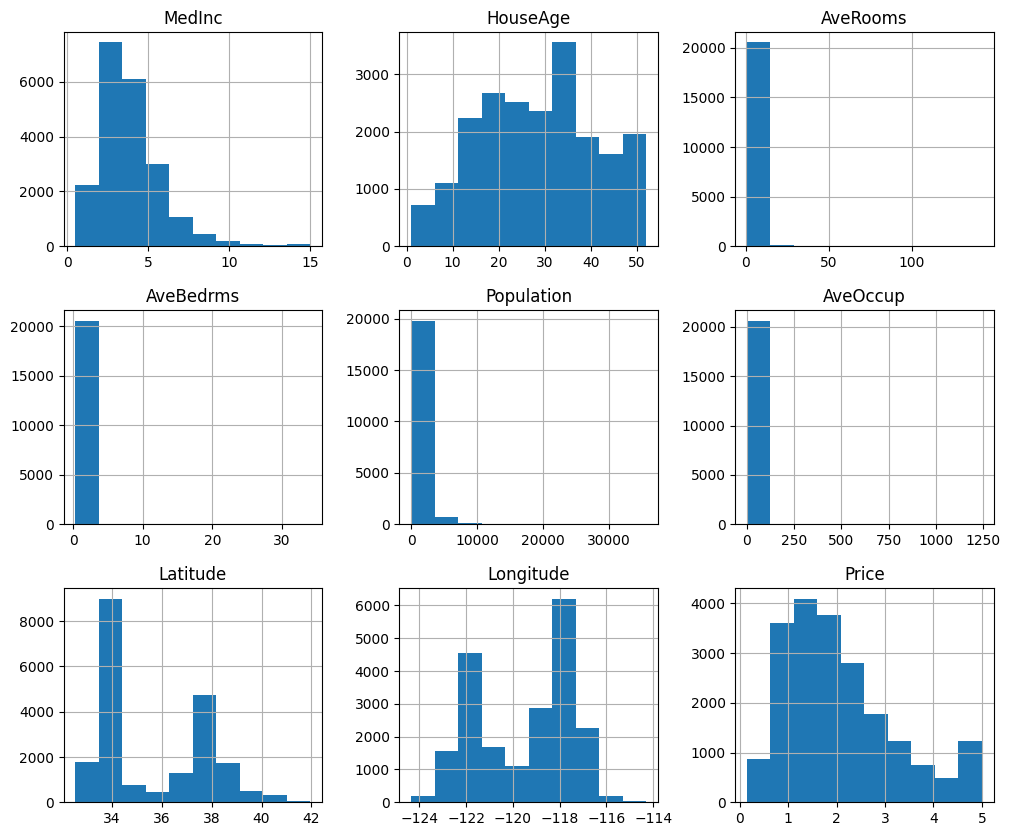

In [22]:
import matplotlib.pyplot as plt

df.hist(figsize=(12, 10))
plt.show()

## 2.5 Correlation Analysis

Correlation analysis was performed to identify relationships between input features and house prices.

In [23]:
corr_matrix = df.corr()

corr_matrix["Price"].sort_values(ascending=False)

,Price
Price,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


# Phase 3: Data Preprocessing

Data preprocessing was carried out to prepare the dataset for machine learning. Features and target variables were separated, data was split into training and testing sets, and feature scaling was applied.
## 3.1 Feature and Target Separation

Independent variables were stored in X, while the target variable (Price) was stored in y.

In [24]:
X = df.drop("Price", axis=1)

y = df["Price"]

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


## 3.2 Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio to evaluate model performance on unseen data.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


## 3.3 Feature Scaling

StandardScaler was used to standardize feature values and bring them to a common scale.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print(X_train[:5])

[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 -0.25753771 -0.44981806 -0.03227969
  -0.46014647 -0.44760309]
 [-1.01786438  0.58654547 -0.60001532 -0.14515634 -0.00743434  0.07750687
  -1.38217186  1.23269811]
 [-0.17148831  1.14200767  0.3490073   0.08662432 -0.48587717 -0.06883176
   0.5320839  -0.10855122]]


# Phase 4: Model Training

A Linear Regression model was trained on the processed training dataset to learn the relationship between housing features and prices.

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

# Phase 5: Prediction and Evaluation

The trained model was used to predict house prices on the test dataset. Model performance was evaluated using Mean Squared Error (MSE) and R² Score.

In [28]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


In [29]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.5558915986952442


In [30]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.575787706032451


### Linear Regression Results

MSE: 0.5559

R² Score: 0.5758

# Phase 6: Model Improvement

To improve prediction performance, a Random Forest Regressor was trained and compared with the baseline Linear Regression model.

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MSE:", rf_mse)
print("Random Forest R²:", rf_r2)

Random Forest MSE: 0.255169737347244
Random Forest R²: 0.8052747336256919


### Random Forest Results

MSE: 0.2552

R² Score: 0.8053

# Phase 7: Visualization

An Actual vs Predicted scatter plot was created to visually assess the prediction accuracy of the Random Forest model.

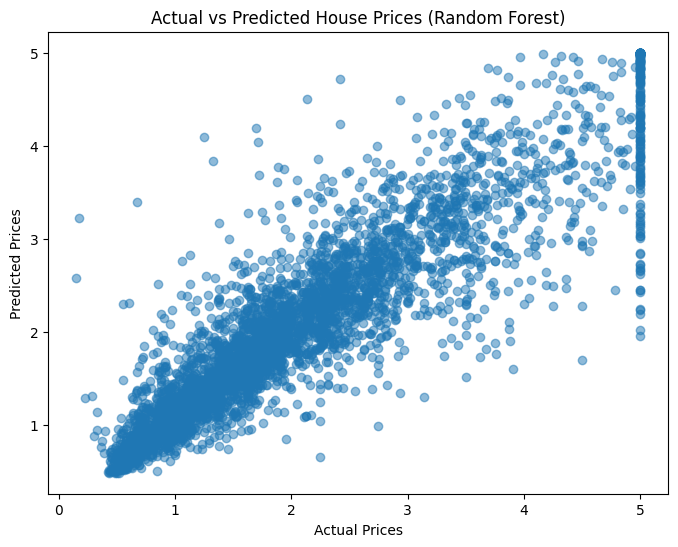

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred, alpha=0.5)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices (Random Forest)")

plt.show()

# Conclusion

The California Housing Dataset was analyzed using machine learning techniques for house price prediction.

EDA was performed to understand data distributions, feature relationships, and data quality. The dataset was preprocessed through train-test splitting and feature scaling.

Two regression models were evaluated:

- Linear Regression
- Random Forest Regressor

Linear Regression achieved an R² score of 0.5758, while Random Forest Regressor achieved an R² score of 0.8053.

Random Forest Regressor outperformed Linear Regression and was selected as the best model for predicting house prices.